# Avance 1 – Análisis Exploratorio de Datos (EDA)

## Contexto
El dataset corresponde al historial transaccional de gastos de viaje de FIRA extraído de SAP.  
Cubre registros desde enero 2018 hasta mayo 2026 (fecha contable).  
La unidad de observación del modelo final será **unidad de primer nivel × partida presupuestal × mes**; el EDA opera al nivel granular de concepto de gasto.

### Preguntas guía del EDA
1. ¿Hay valores faltantes? ¿Se pueden identificar patrones de ausencia?
2. ¿Cuáles son las estadísticas resumidas del conjunto?
3. ¿Hay valores atípicos?
4. ¿Cuál es la cardinalidad de las variables categóricas?
5. ¿Existen distribuciones sesgadas? ¿Se necesita transformación no lineal?
6. ¿Se identifican tendencias temporales?
7. ¿Hay correlación entre variables dependientes e independientes?
8. ¿Cómo se distribuyen los datos por categoría (análisis bivariado)?
9. ¿Hay desequilibrio en las clases de la variable objetivo?

---
## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

PALETTE = ['#1a5276', '#2980b9', '#85c1e9', '#e74c3c', '#e67e22',
           '#2ecc71', '#8e44ad', '#f39c12', '#1abc9c', '#c0392b',
           '#16a085', '#d35400']
sns.set_style('whitegrid')
sns.set_palette(PALETTE)

print('Librerías cargadas.')

Librerías cargadas.


---
## 1. Carga de datos

In [2]:
DATA_PATH = 'historico_SAP_2.parquet'

df_raw = pd.read_parquet(DATA_PATH)
print(f'Registros: {len(df_raw):,}')
print(f'Columnas : {df_raw.shape[1]}')
df_raw.head(3)

Registros: 506,149
Columnas : 17


,Clave Empleado,Viaje,Clave Concepto,Concepto,Fecha Contable,Cuenta Contable,Partida Presupuestal,Funcionario o resto de personal,Grupo Tipo Viaje,Clave Centro Costo,Fecha inicio,Fecha Final,Documento Contable,Monto Gasto,Destino,Periodo,Zona
0,"9,146.00","3,924.00",132,Cuota sin comprobar,2019-08-02,5302937504,37504,FUNCIONARIO,GC,10000000,2019-07-22,2019-07-23,1280021356,232.00,"MORELIA, MCH",1,Zona B
1,"9,146.00","3,924.00",131,Alimentación-Hospedaje,2019-08-02,5302937504,37504,FUNCIONARIO,GC,10000000,2019-07-22,2019-07-23,1280021356,"1,814.54","MORELIA, MCH",1,Zona B
2,"9,146.00","3,924.00",129,Impuestos Alim-Hosp,2019-08-02,5302937504,37504,FUNCIONARIO,GC,10000000,2019-07-22,2019-07-23,1280021356,344.77,"MORELIA, MCH",1,Zona B


---
## 2. Estructura del dataset
### 2.1 Tipos de datos y descripción de columnas

In [3]:
col_desc = {
    'Clave Empleado'                 : 'ID numérico del empleado en SAP',
    'Viaje'                          : 'ID del viaje en SAP (empleado + viaje = viaje único)',
    'Clave Concepto'                 : 'Código del concepto de gasto',
    'Concepto'                       : 'Descripción del concepto de gasto',
    'Fecha Contable'                 : 'Fecha en que Contabilidad autorizó y registró el gasto',
    'Cuenta Contable'                : 'Cuenta contable SAP',
    'Partida Presupuestal'           : 'Partida presupuestal (8 partidas vigiladas)',
    'Funcionario o resto de personal': 'Categoría del empleado: FUNCIONARIO / RESTO DE PERSONAL',
    'Grupo Tipo Viaje'               : 'GC = Gasto Corriente / CAP = Capacitación',
    'Clave Centro Costo'             : 'Centro de costo SAP',
    'Fecha inicio'                   : 'Fecha de inicio del viaje',
    'Fecha Final'                    : 'Fecha de fin del viaje',
    'Documento Contable'             : 'Número de documento contable SAP',
    'Monto Gasto'                    : 'Monto del concepto en MXN (negativo = ajuste)',
    'Destino'                        : 'Destino del viaje',
    'Periodo'                        : 'Período tarifario vigente al momento del viaje (1, 2 o 3)',
    'Zona'                           : 'Zona tarifaria del destino (Zona A / Zona B; en periodo 3 todo es Zona A)',
}

desc_df = pd.DataFrame({
    'Dtype'       : df_raw.dtypes,
    'Descripción' : col_desc,
    'Nulos'       : df_raw.isnull().sum(),
    '% Nulos'     : (df_raw.isnull().sum() / len(df_raw) * 100).round(3),
    'Cardinalidad': df_raw.nunique(),
})
desc_df

,Dtype,Descripción,Nulos,% Nulos,Cardinalidad
Clave Empleado,float64,ID numérico del empleado en SAP,33,0.01,1567
Viaje,float64,ID del viaje en SAP (empleado + viaje = viaje ...,33,0.01,22438
Clave Concepto,int64,Código del concepto de gasto,0,0.00,22
Concepto,str,Descripción del concepto de gasto,0,0.00,21
Fecha Contable,datetime64[ns],Fecha en que Contabilidad autorizó y registró ...,0,0.00,2251
Cuenta Contable,int64,Cuenta contable SAP,0,0.00,9
Partida Presupuestal,int64,Partida presupuestal (8 partidas vigiladas),0,0.00,9
Funcionario o resto de personal,str,Categoría del empleado: FUNCIONARIO / RESTO DE...,0,0.00,2
Grupo Tipo Viaje,str,GC = Gasto Corriente / CAP = Capacitación,33,0.01,2
Clave Centro Costo,int64,Centro de costo SAP,0,0.00,238


### 2.2 Estadísticas descriptivas

In [4]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Clave Empleado,"506,116.00",NaN,NaN,NaN,"87,694.31","9,146.00","81,512.00","90,517.00","90,847.00","91,473.00","5,138.71"
Viaje,"506,116.00",NaN,NaN,NaN,"5,735.66",2.00,"2,991.75","4,013.00","5,843.00","26,333.00","5,026.71"
Clave Concepto,"506,149.00",NaN,NaN,NaN,129.79,0.00,130.00,132.00,133.00,138.00,10.59
Concepto,506149,21,Cuota sin comprobar,148995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha Contable,506149,NaN,NaN,NaN,2021-09-21 04:11:54.012672256,2018-01-02 00:00:00,2019-03-13 00:00:00,2021-07-29 00:00:00,2024-03-25 00:00:00,2026-05-05 00:00:00,NaN
Cuenta Contable,"506,149.00",NaN,NaN,NaN,"5,302,934,940.69","5,302,232,502.00","5,302,937,201.00","5,302,937,501.00","5,302,937,501.00","5,302,937,504.00","11,334.75"
Partida Presupuestal,"506,149.00",NaN,NaN,NaN,"35,092.82","26,102.00","37,201.00","37,501.00","37,501.00","37,504.00","4,606.60"
Funcionario o resto de personal,506149,2,RESTO DE PERSONAL,472333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grupo Tipo Viaje,506116,2,GC,485624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Clave Centro Costo,"506,149.00",NaN,NaN,NaN,"18,168,651.71","10,000,000.00","19,020,100.00","19,030,502.00","19,040,501.00","19,050,602.00","2,220,964.89"


---
## 3. Calidad de datos
### 3.1 Valores faltantes – patrón de ausencia

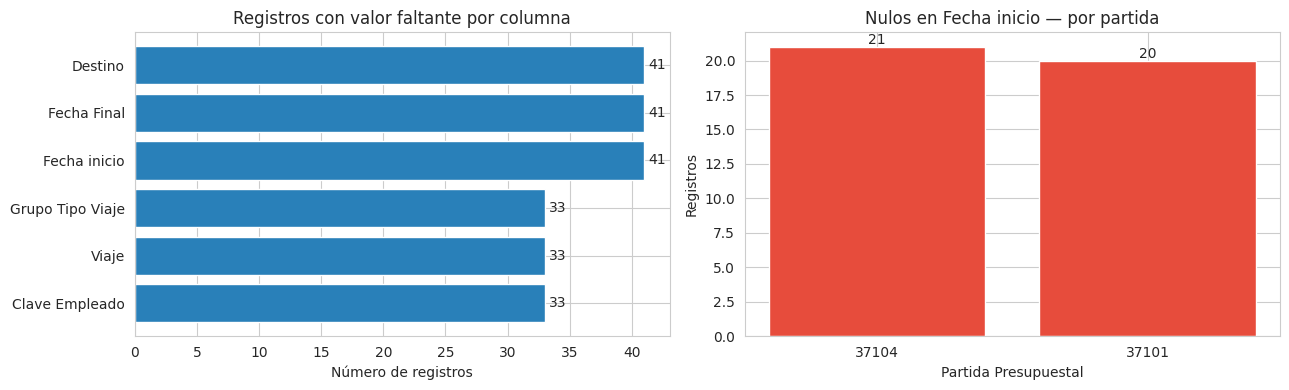


HALLAZGO – Valores faltantes:
El dataset tiene muy pocos nulos (<0.02% del total), todos en partidas de avión
(37101 y 37104), con dos causas de negocio distintas:

1. Nulos en 'Fecha inicio' y 'Fecha Final' (41 registros):
   Comisiones que no se realizaron pero generaron un cargo de pasaje aéreo.
   El vuelo fue cobrado por la agencia aunque el viaje no ocurrió, por lo que
   no existe fecha de comisión que registrar en SAP.
   Estrategia: conservarlos como gasto ejercido (el cargo es real);
   usar Fecha Contable como referencia temporal. No imputar fechas de viaje.

2. Nulos en 'Clave Empleado', 'Viaje' y 'Grupo Tipo Viaje' (33 registros):
   Cargos de avión que SAP no pudo asociar a un viaje ni a un empleado específico.
   El gasto existe contablemente pero sin trazabilidad al nivel de persona o comisión.
   Estrategia: incluirlos en el gasto agregado mensual por partida y centro de costo
   (impactan el presupuesto); excluirlos de análisis que requieran atributos del empleado.



In [5]:
cols_con_nulos = df_raw.columns[df_raw.isnull().any()].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfica 1: conteo de nulos por columna
nulos_conteo = df_raw[cols_con_nulos].isnull().sum().sort_values(ascending=True)
axes[0].barh(nulos_conteo.index, nulos_conteo.values, color='#2980b9', edgecolor='white')
axes[0].set_title('Registros con valor faltante por columna')
axes[0].set_xlabel('Número de registros')
for i, v in enumerate(nulos_conteo.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=10)

# Gráfica 2: nulos en Fecha inicio por partida
nulos_partida = df_raw[df_raw['Fecha inicio'].isnull()]['Partida Presupuestal'].value_counts()
axes[1].bar(nulos_partida.index.astype(str), nulos_partida.values, color='#e74c3c', edgecolor='white')
axes[1].set_title('Nulos en Fecha inicio — por partida')
axes[1].set_xlabel('Partida Presupuestal')
axes[1].set_ylabel('Registros')
for i, v in enumerate(nulos_partida.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("""
HALLAZGO – Valores faltantes:
El dataset tiene muy pocos nulos (<0.02% del total), todos en partidas de avión
(37101 y 37104), con dos causas de negocio distintas:

1. Nulos en 'Fecha inicio' y 'Fecha Final' (41 registros):
   Comisiones que no se realizaron pero generaron un cargo de pasaje aéreo.
   El vuelo fue cobrado por la agencia aunque el viaje no ocurrió, por lo que
   no existe fecha de comisión que registrar en SAP.
   Estrategia: conservarlos como gasto ejercido (el cargo es real);
   usar Fecha Contable como referencia temporal. No imputar fechas de viaje.

2. Nulos en 'Clave Empleado', 'Viaje' y 'Grupo Tipo Viaje' (33 registros):
   Cargos de avión que SAP no pudo asociar a un viaje ni a un empleado específico.
   El gasto existe contablemente pero sin trazabilidad al nivel de persona o comisión.
   Estrategia: incluirlos en el gasto agregado mensual por partida y centro de costo
   (impactan el presupuesto); excluirlos de análisis que requieran atributos del empleado.

En ambos casos la Fecha Contable está disponible, por lo que ningún registro
queda fuera del análisis temporal ni del cómputo presupuestal.
""")

### 3.2 Montos negativos (ajustes/cancelaciones)

In [6]:
neg = df_raw[df_raw['Monto Gasto'] < 0]
print(f'Registros con monto negativo: {len(neg)} ({len(neg)/len(df_raw)*100:.3f}%)')
print(f'Suma de montos negativos: ${neg["Monto Gasto"].sum():,.2f}')
print(f'\nDistribución por partida:')
print(neg.groupby('Partida Presupuestal')['Monto Gasto'].agg(['count','sum']).rename(
    columns={'count':'n_registros','sum':'suma_mxn'}))
print(f'\nDistribución por concepto (top 10):')
print(neg.groupby('Concepto')['Monto Gasto'].agg(['count','sum']).sort_values('count', ascending=False).head(10))

print("""
HALLAZGO – Montos negativos:
Los 94 registros con monto negativo representan ajustes o reversiones de gastos ya
registrados. Son contablemente válidos: un gasto que se revierte genera un concepto
de signo contrario en SAP.

Estrategia:
  - Conservarlos en el cálculo del gasto agregado mensual (se netean correctamente).
  - No deben imputarse a cero ni eliminarse; hacerlo sobreestimaría el gasto real.
""")

Registros con monto negativo: 94 (0.019%)
Suma de montos negativos: $-111,944.59

Distribución por partida:
                      n_registros   suma_mxn
Partida Presupuestal                        
26102                           3  -2,357.95
26104                           1  -1,367.40
37201                          23  -8,668.82
37204                           1    -262.00
37501                          62 -94,055.33
37504                           4  -5,233.09

Distribución por concepto (top 10):
                                count        sum
Concepto                                        
Impuestos Alim-Hosp                22  -6,742.10
Alimentación-Hospedaje             18 -79,910.42
Peajes con CFDI                    16  -6,517.02
Cuota sin comprobar                14  -8,624.00
Alimentación sin Pernocta          12  -4,011.90
Gasolina Auto c/financiamiento      4  -3,725.35
Peajes sin CFDI                     4  -1,287.00
Estacionamiento sin CFDI            3    -198.00
Cuota

### 3.3 Partida 32502 – Renta de Vehículo (fuera del alcance del modelo)

In [7]:
print('Partidas únicas en el dataset:')
print(df_raw['Partida Presupuestal'].value_counts().to_frame())

print("""
HALLAZGO: La partida 32502 (Renta de Vehículo, 110 registros) no forma parte de las
8 partidas presupuestales vigiladas. Se excluirá del dataset de modelado.
""")

PARTIDAS_MODELO = [26102, 26104, 37101, 37104, 37201, 37204, 37501, 37504]
df = df_raw[df_raw['Partida Presupuestal'].isin(PARTIDAS_MODELO)].copy()
print(f'Dataset de trabajo (8 partidas): {len(df):,} registros')

Partidas únicas en el dataset:
                       count
Partida Presupuestal        
37501                 315182
26102                 101374
37201                  53714
37504                  21828
37204                   7452
26104                   3813
37101                   1953
37104                    723
32502                    110

HALLAZGO: La partida 32502 (Renta de Vehículo, 110 registros) no forma parte de las
8 partidas presupuestales vigiladas. Se excluirá del dataset de modelado.



Dataset de trabajo (8 partidas): 506,039 registros


### 3.4 Desfase contable: Fecha Contable vs. Fecha de inicio del viaje

Estadísticas del desfase contable (días entre inicio del viaje y registro contable):
                  count  mean   std     min  25%  50%   75%      max
desfase_dias 505,998.00 11.25 10.92 -340.00 6.00 9.00 14.00 1,454.00


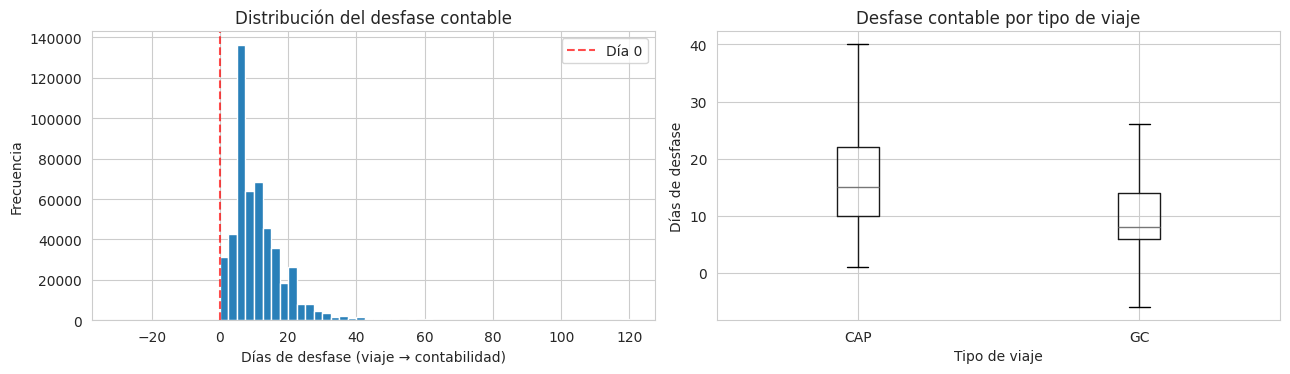

Registros con desfase negativo: 23
Desfase mediano: 9 días
Desfase P90: 21 días

HALLAZGO – Desfase contable:
El gasto se registra contablemente varios días después del viaje (mediana ~7–14 días,
con colas hasta >60 días). Los registros con desfase negativo corresponden a pasajes
aéreos donde la Fecha inicio puede ser anterior a la liquidación batch mensual.

Implicación para el modelo:
  - Se usará FECHA CONTABLE como referencia presupuestal.
  - El desfase se incorporará como variable en A2.



In [8]:
df_desfase = df.dropna(subset=['Fecha inicio']).copy()
df_desfase['desfase_dias'] = (df_desfase['Fecha Contable'] - df_desfase['Fecha inicio']).dt.days

print('Estadísticas del desfase contable (días entre inicio del viaje y registro contable):')
print(df_desfase['desfase_dias'].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_desfase['desfase_dias'].clip(-30, 120), bins=60, color='#2980b9', edgecolor='white')
axes[0].set_xlabel('Días de desfase (viaje → contabilidad)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del desfase contable')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Día 0')
axes[0].legend()

df_desfase.boxplot(column='desfase_dias', by='Grupo Tipo Viaje',
                   ax=axes[1], showfliers=False)
axes[1].set_title('Desfase contable por tipo de viaje')
axes[1].set_xlabel('Tipo de viaje')
axes[1].set_ylabel('Días de desfase')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f'Registros con desfase negativo: {(df_desfase["desfase_dias"] < 0).sum()}')
print(f'Desfase mediano: {df_desfase["desfase_dias"].median():.0f} días')
print(f'Desfase P90: {df_desfase["desfase_dias"].quantile(0.9):.0f} días')

print("""
HALLAZGO – Desfase contable:
El gasto se registra contablemente varios días después del viaje (mediana ~7–14 días,
con colas hasta >60 días). Los registros con desfase negativo corresponden a pasajes
aéreos donde la Fecha inicio puede ser anterior a la liquidación batch mensual.

Implicación para el modelo:
  - Se usará FECHA CONTABLE como referencia presupuestal.
  - El desfase se incorporará como variable en A2.
""")

---
## 4. Análisis Univariado
### 4.1 Variable objetivo: Monto Gasto

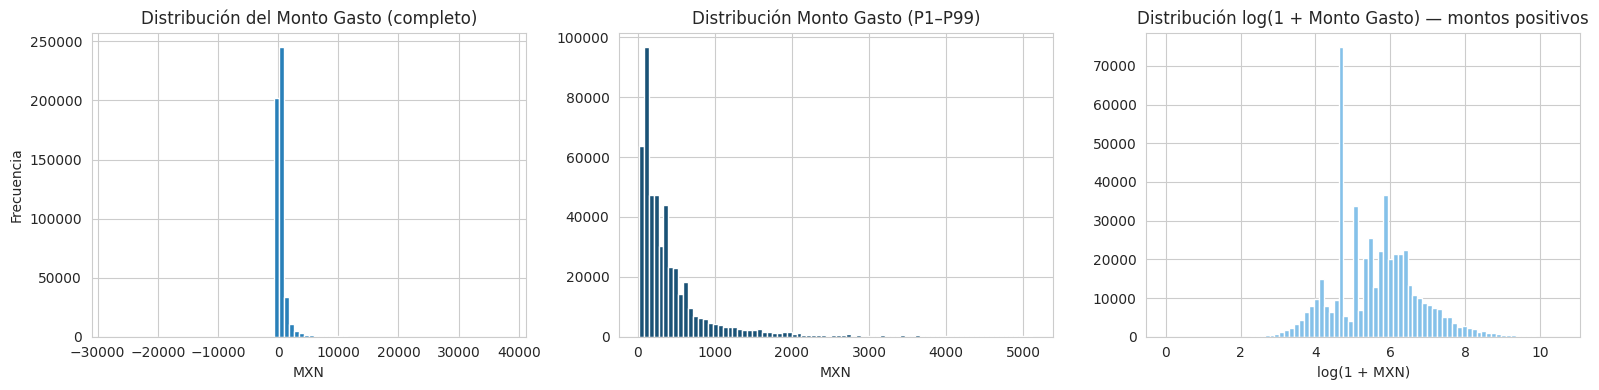

Asimetría (skew): 8.75
Curtosis          : 128.26

Escala log: asimetría = 0.34, curtosis = 0.21

HALLAZGO – Distribución del Monto Gasto:
La distribución es fuertemente asimétrica a la derecha (skew > 8): la mayoría de
conceptos son montos pequeños (cuotas, peajes, gasolina diaria) y una cola larga
corresponde a aviones y viajes largos de funcionarios.

La transformación log(1+x) reduce drásticamente la asimetría y acerca la
distribución a la normal. Las dos 'jorobas' visibles en escala log reflejan
los dos grupos naturales del dataset: resto de personal (montos más bajos)
y funcionarios (montos más altos, con tarifas ~65% superiores).

→ El baseline lineal (A3) requerirá transformación log.
→ XGBoost y Random Forest son robustos al sesgo sin transformación.



In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['Monto Gasto'], bins=80, color='#2980b9', edgecolor='white')
axes[0].set_title('Distribución del Monto Gasto (completo)')
axes[0].set_xlabel('MXN')
axes[0].set_ylabel('Frecuencia')

p1, p99 = df['Monto Gasto'].quantile([0.01, 0.99])
df_trim = df[(df['Monto Gasto'] >= p1) & (df['Monto Gasto'] <= p99)]
axes[1].hist(df_trim['Monto Gasto'], bins=80, color='#1a5276', edgecolor='white')
axes[1].set_title('Distribución Monto Gasto (P1–P99)')
axes[1].set_xlabel('MXN')

pos_montos = df[df['Monto Gasto'] > 0]['Monto Gasto']
axes[2].hist(np.log1p(pos_montos), bins=80, color='#85c1e9', edgecolor='white')
axes[2].set_title('Distribución log(1 + Monto Gasto) — montos positivos')
axes[2].set_xlabel('log(1 + MXN)')

plt.tight_layout()
plt.show()

print(f'Asimetría (skew): {df["Monto Gasto"].skew():.2f}')
print(f'Curtosis          : {df["Monto Gasto"].kurt():.2f}')
print(f'\nEscala log: asimetría = {np.log1p(pos_montos).skew():.2f}, curtosis = {np.log1p(pos_montos).kurt():.2f}')

print("""
HALLAZGO – Distribución del Monto Gasto:
La distribución es fuertemente asimétrica a la derecha (skew > 8): la mayoría de
conceptos son montos pequeños (cuotas, peajes, gasolina diaria) y una cola larga
corresponde a aviones y viajes largos de funcionarios.

La transformación log(1+x) reduce drásticamente la asimetría y acerca la
distribución a la normal. Las dos 'jorobas' visibles en escala log reflejan
los dos grupos naturales del dataset: resto de personal (montos más bajos)
y funcionarios (montos más altos, con tarifas ~65% superiores).

→ El baseline lineal (A3) requerirá transformación log.
→ XGBoost y Random Forest son robustos al sesgo sin transformación.
""")

### 4.2 Variables categóricas – cardinalidad y frecuencias

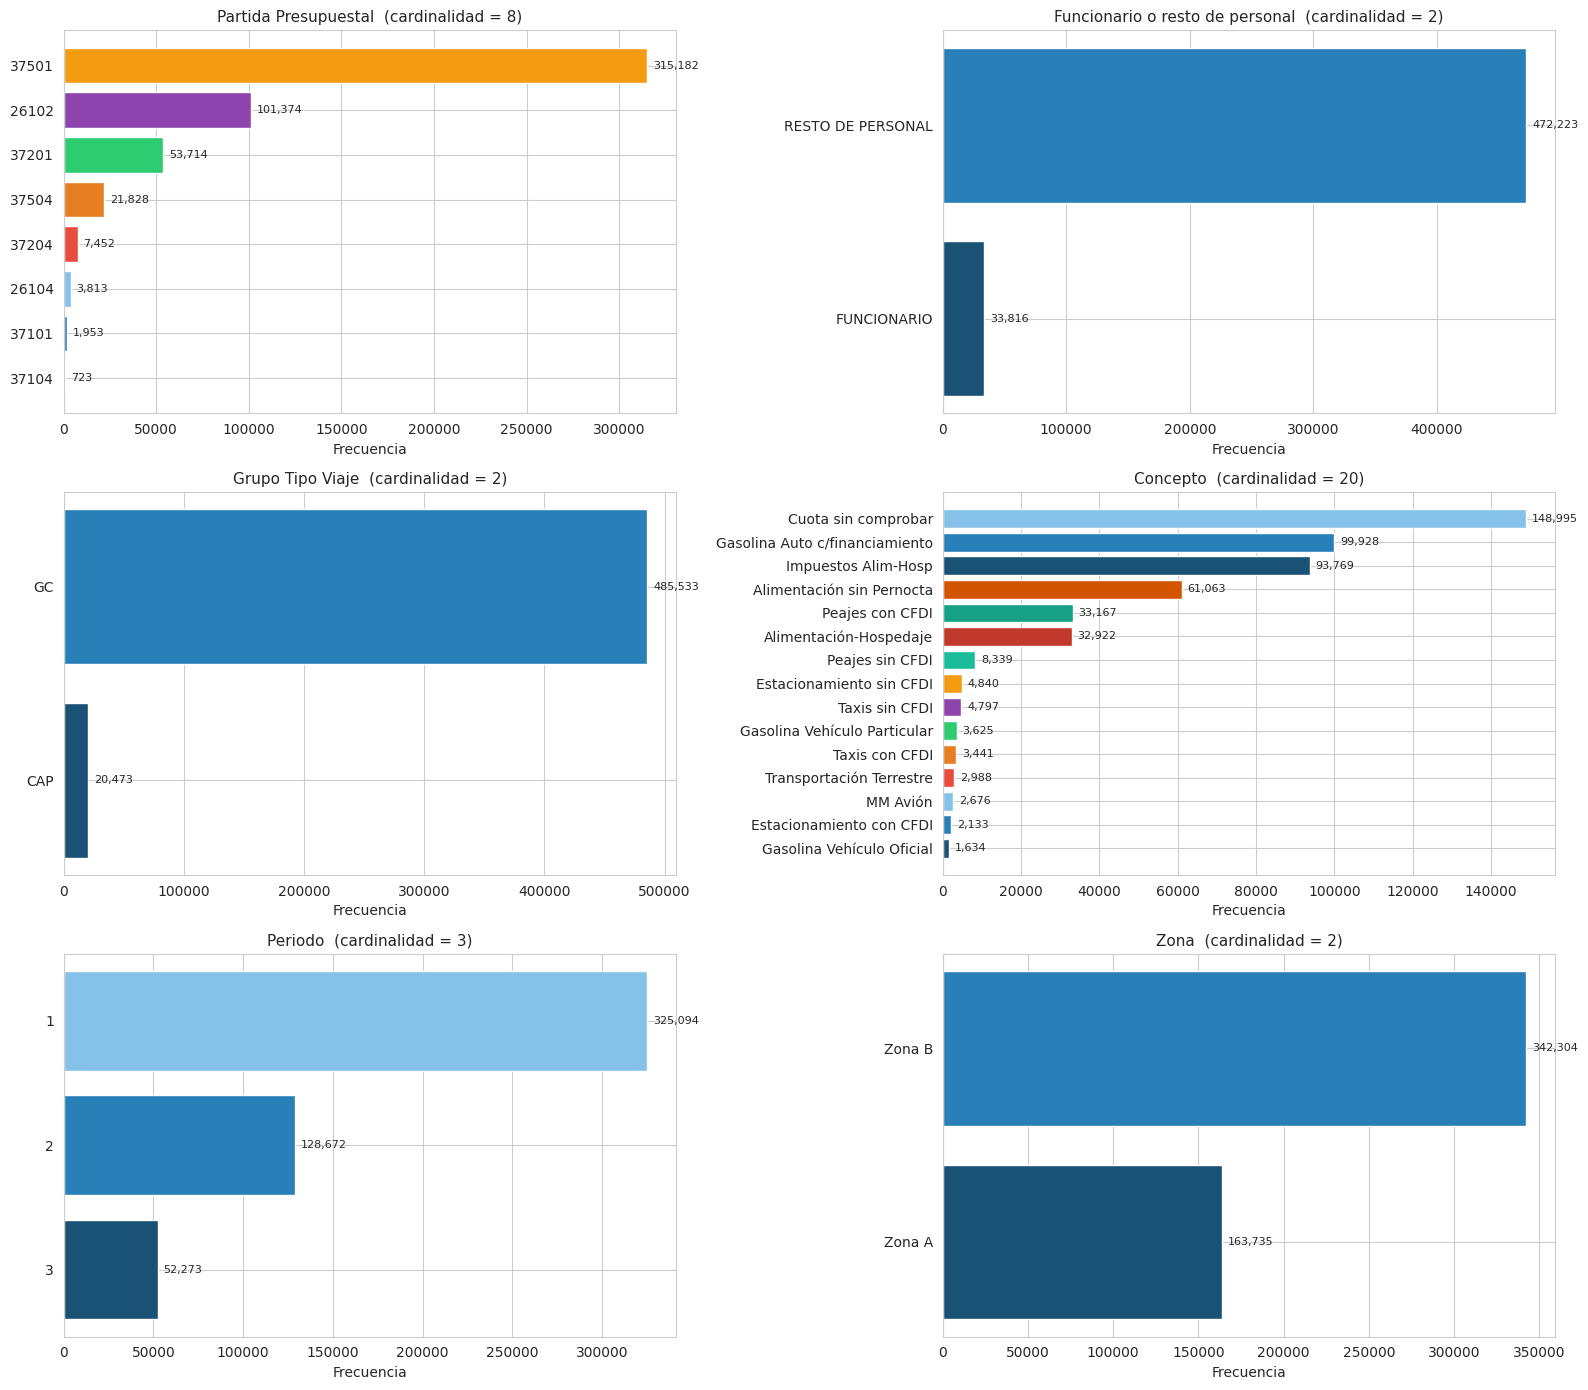

Cardinalidades clave:
  Partida Presupuestal: 8 valores únicos
  Funcionario o resto de personal: 2 valores únicos
  Grupo Tipo Viaje: 2 valores únicos
  Concepto: 20 valores únicos
  Periodo: 3 valores únicos
  Zona: 2 valores únicos
  Clave Empleado: 1567 valores únicos
  Viaje: 22438 valores únicos
  Clave Centro Costo: 238 valores únicos
  Destino: 1802 valores únicos


In [10]:
cat_cols = ['Partida Presupuestal', 'Funcionario o resto de personal',
            'Grupo Tipo Viaje', 'Concepto', 'Periodo', 'Zona']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    top = vc.head(15)
    axes[i].barh(top.index.astype(str)[::-1], top.values[::-1], color=PALETTE[:len(top)])
    axes[i].set_title(f'{col}  (cardinalidad = {df[col].nunique()})', fontsize=11)
    axes[i].set_xlabel('Frecuencia')
    for j, v in enumerate(top.values[::-1]):
        axes[i].text(v + max(top.values)*0.01, j, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('Cardinalidades clave:')
for col in cat_cols + ['Clave Empleado', 'Viaje', 'Clave Centro Costo', 'Destino']:
    print(f'  {col}: {df[col].nunique()} valores únicos')

In [11]:
# Distribución de Zona por Periodo
print('Registros por Periodo y Zona:')
print(pd.crosstab(df['Periodo'], df['Zona'], margins=True))

print("""
HALLAZGO – Periodo y Zona:
  Periodo 1 (ene-2018 a jul-2023): mayor volumen (~325K registros). Zona B predomina
    porque la mayoría de destinos estaban clasificados en Zona B.
  Periodo 2 (jul-2023 a jun-2025): se reclasificaron destinos, aumentando Zona A.
    Las tarifas no cambiaron, solo el listado de qué destinos pertenecen a cada zona.
  Periodo 3 (jun-2025 en adelante): se eliminó la distinción entre zonas; todos los
    destinos se registran como Zona A con tarifas únicas más altas.

→ Esta distinción es crítica para la normalización: el mismo destino puede tener
  tarifa diferente en periodos 1 y 2. Se usará la columna 'Periodo' y 'Zona'
  del dataset (ya viene resuelta desde SAP) en lugar de inferirla.
""")

Registros por Periodo y Zona:


Zona     Zona A  Zona B     All
Periodo                        
1         74844  250250  325094
2         36618   92054  128672
3         52273       0   52273
All      163735  342304  506039

HALLAZGO – Periodo y Zona:
  Periodo 1 (ene-2018 a jul-2023): mayor volumen (~325K registros). Zona B predomina
    porque la mayoría de destinos estaban clasificados en Zona B.
  Periodo 2 (jul-2023 a jun-2025): se reclasificaron destinos, aumentando Zona A.
    Las tarifas no cambiaron, solo el listado de qué destinos pertenecen a cada zona.
  Periodo 3 (jun-2025 en adelante): se eliminó la distinción entre zonas; todos los
    destinos se registran como Zona A con tarifas únicas más altas.

→ Esta distinción es crítica para la normalización: el mismo destino puede tener
  tarifa diferente en periodos 1 y 2. Se usará la columna 'Periodo' y 'Zona'
  del dataset (ya viene resuelta desde SAP) en lugar de inferirla.



### 4.3 Cobertura temporal

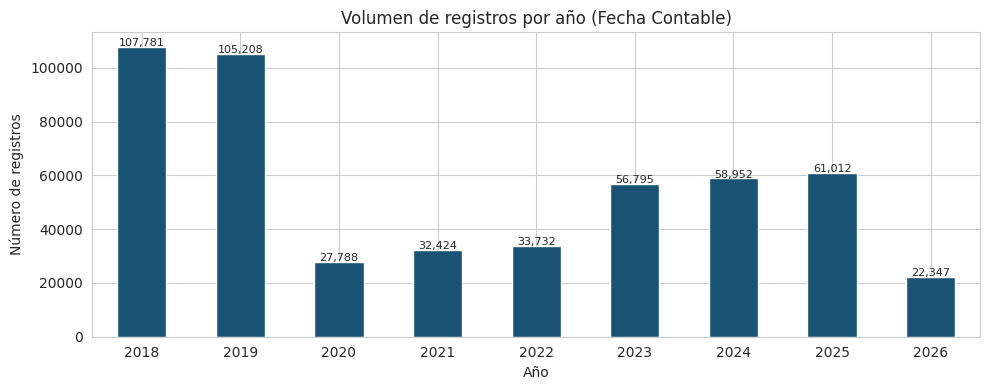


HALLAZGO – Cobertura temporal:
  2018–2019: volumen normal (~100K registros/año).
  2020–2022: caída marcada por COVID-19 (2020 especialmente bajo).
  2023–2025: recuperación y retorno a niveles pre-pandemia.
  2026: solo ene–may (año en curso, incompleto).

→ Los años 2020–2021 se tratarán como período atípico en el modelado.



In [12]:
df['anio']     = df['Fecha Contable'].dt.year
df['mes']      = df['Fecha Contable'].dt.month
df['anio_mes'] = df['Fecha Contable'].dt.to_period('M')

registros_anio = df.groupby('anio').size()

fig, ax = plt.subplots(figsize=(10, 4))
registros_anio.plot(kind='bar', ax=ax, color='#1a5276', edgecolor='white')
ax.set_title('Volumen de registros por año (Fecha Contable)')
ax.set_xlabel('Año')
ax.set_ylabel('Número de registros')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 200,
            f'{int(p.get_height()):,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("""
HALLAZGO – Cobertura temporal:
  2018–2019: volumen normal (~100K registros/año).
  2020–2022: caída marcada por COVID-19 (2020 especialmente bajo).
  2023–2025: recuperación y retorno a niveles pre-pandemia.
  2026: solo ene–may (año en curso, incompleto).

→ Los años 2020–2021 se tratarán como período atípico en el modelado.
""")

---
## 5. Análisis Bivariado
### 5.1 Gasto mensual total – serie de tiempo

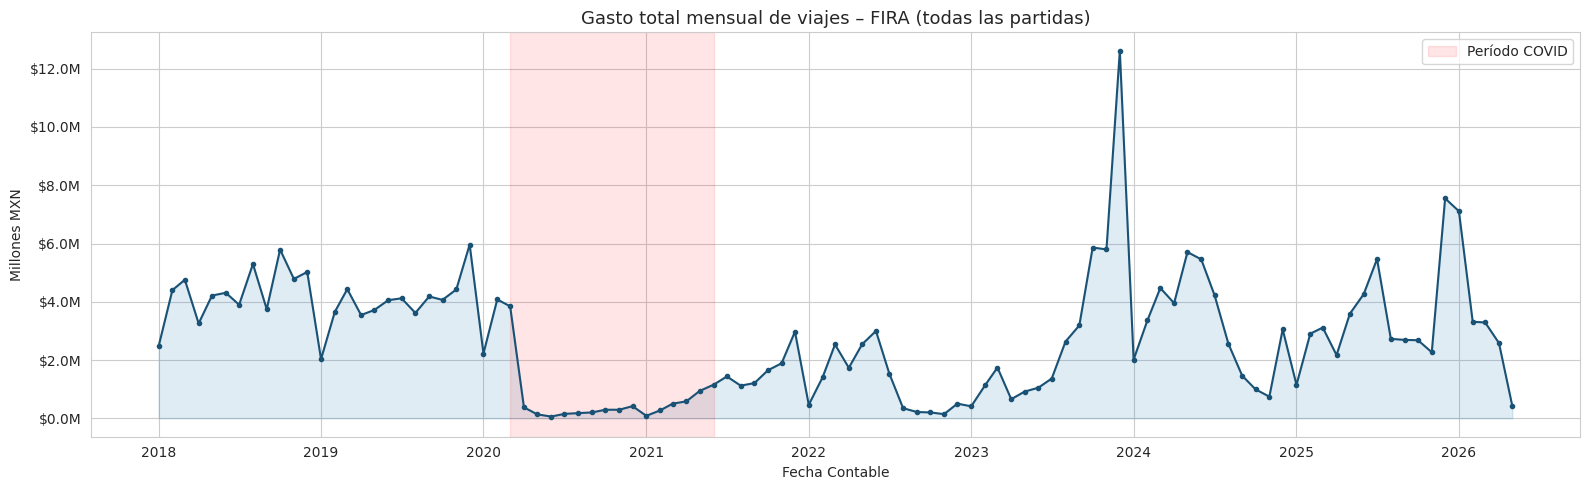

In [13]:
gasto_mensual = df.groupby('anio_mes')['Monto Gasto'].sum().reset_index()
gasto_mensual['fecha'] = gasto_mensual['anio_mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(gasto_mensual['fecha'], gasto_mensual['Monto Gasto']/1e6,
        color='#1a5276', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(gasto_mensual['fecha'], gasto_mensual['Monto Gasto']/1e6,
                alpha=0.15, color='#2980b9')
ax.set_title('Gasto total mensual de viajes – FIRA (todas las partidas)', fontsize=13)
ax.set_xlabel('Fecha Contable')
ax.set_ylabel('Millones MXN')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='red', label='Período COVID')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Gasto mensual por partida presupuestal

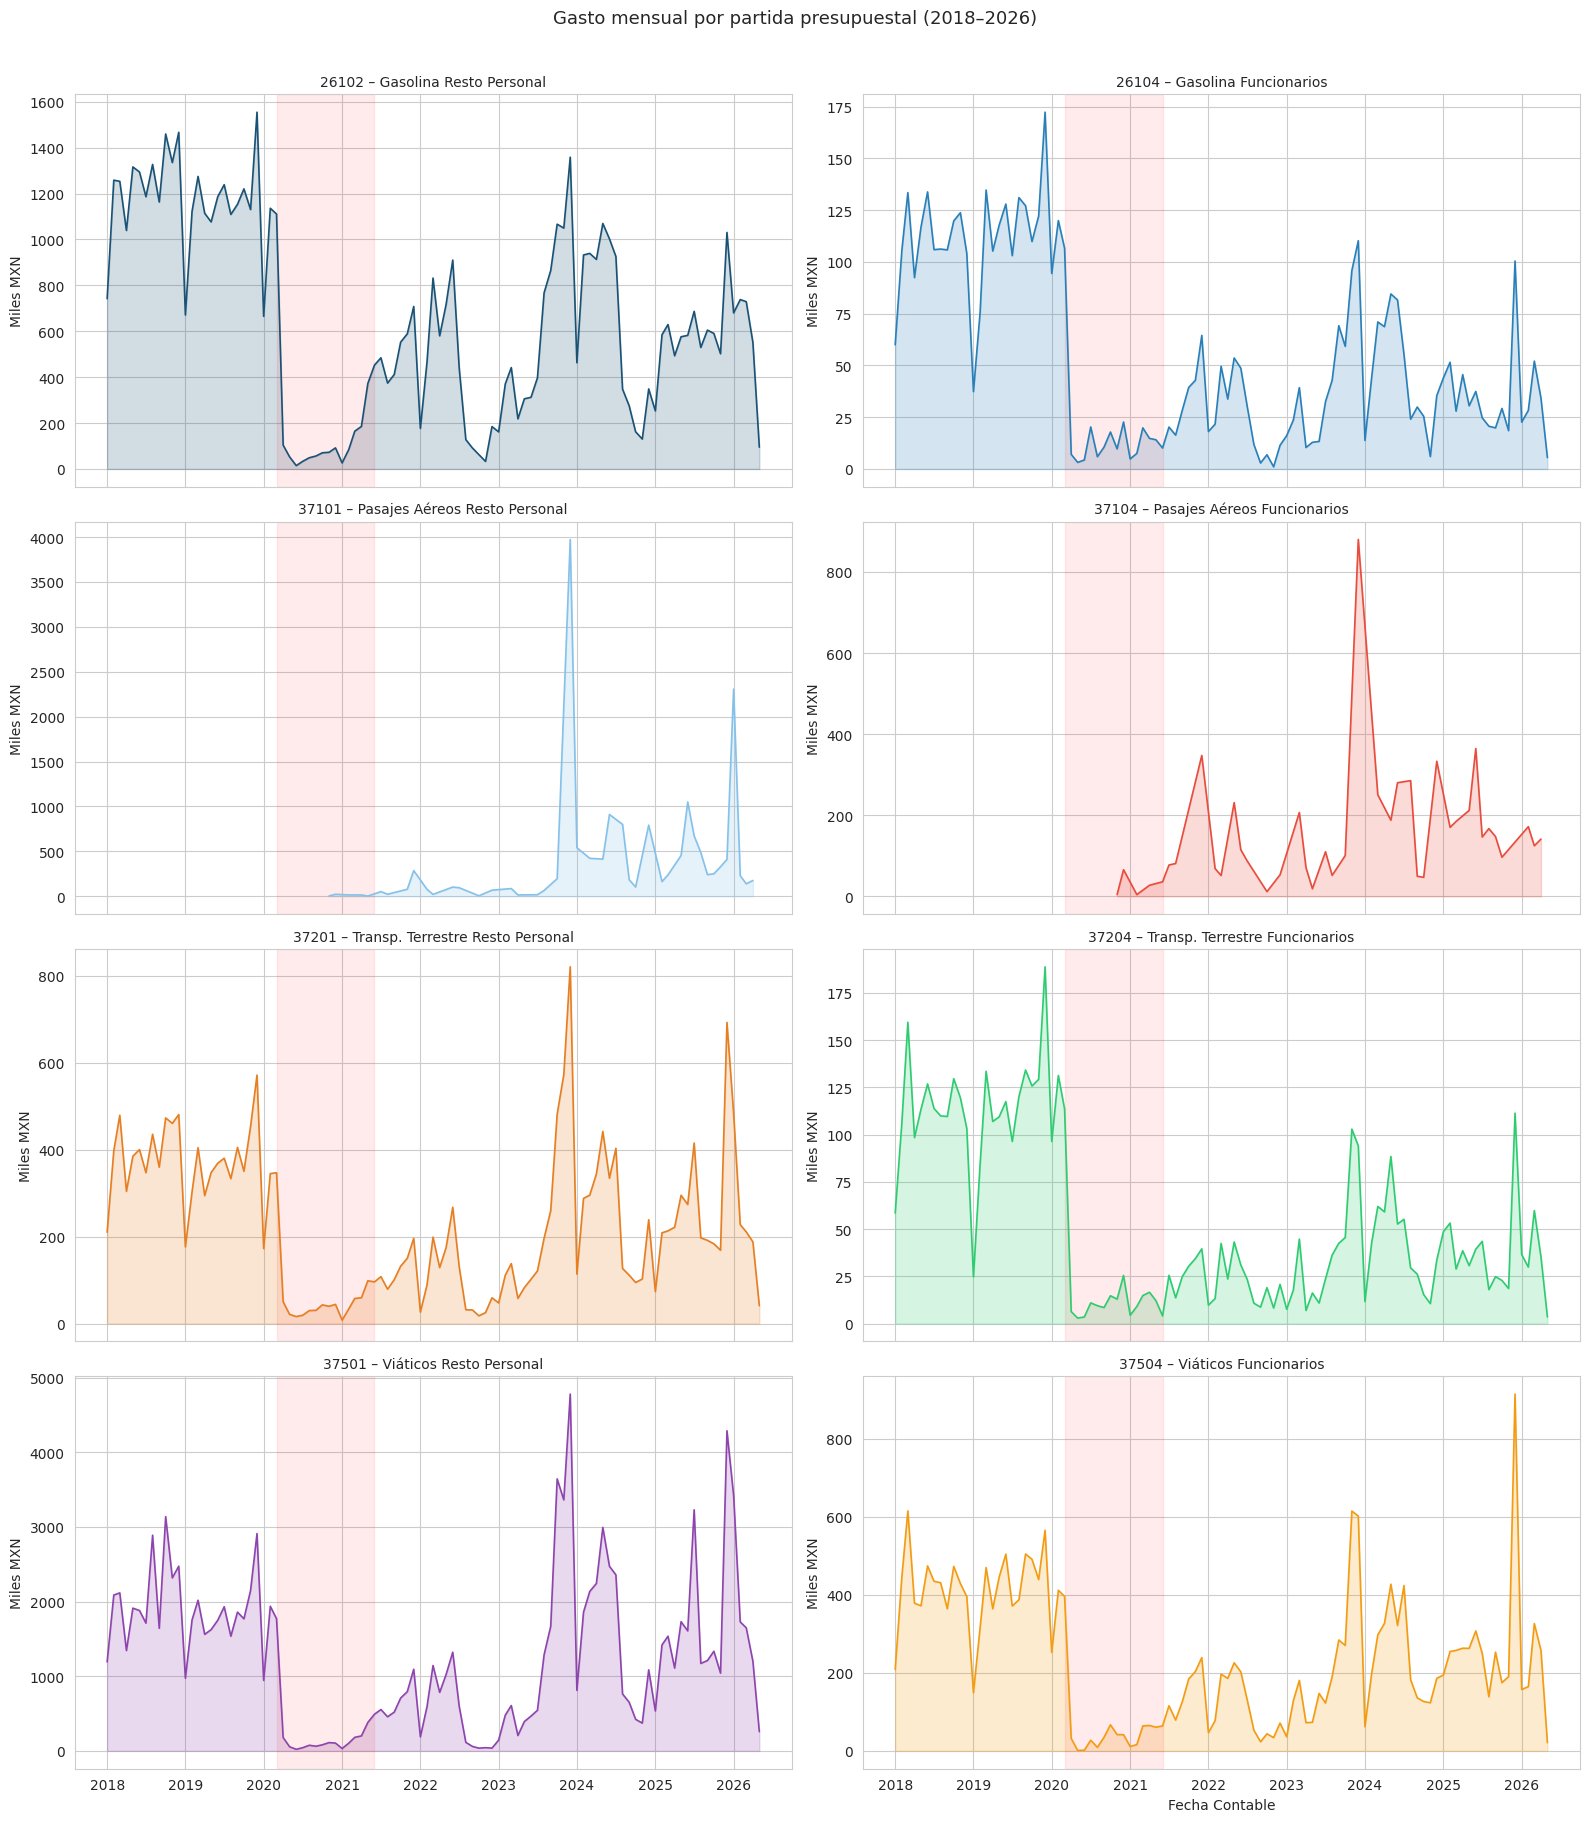

In [14]:
gasto_partida_mes = (df.groupby(['anio_mes', 'Partida Presupuestal'])['Monto Gasto']
                       .sum().reset_index())
gasto_partida_mes['fecha'] = gasto_partida_mes['anio_mes'].dt.to_timestamp()

partidas_labels = {
    26102: '26102 – Gasolina Resto Personal',
    26104: '26104 – Gasolina Funcionarios',
    37101: '37101 – Pasajes Aéreos Resto Personal',
    37104: '37104 – Pasajes Aéreos Funcionarios',
    37201: '37201 – Transp. Terrestre Resto Personal',
    37204: '37204 – Transp. Terrestre Funcionarios',
    37501: '37501 – Viáticos Resto Personal',
    37504: '37504 – Viáticos Funcionarios',
}

fig, axes = plt.subplots(4, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

for i, partida in enumerate(PARTIDAS_MODELO):
    data = gasto_partida_mes[gasto_partida_mes['Partida Presupuestal'] == partida]
    axes[i].plot(data['fecha'], data['Monto Gasto']/1e3, color=PALETTE[i], linewidth=1.2)
    axes[i].fill_between(data['fecha'], data['Monto Gasto']/1e3, alpha=0.2, color=PALETTE[i])
    axes[i].set_title(partidas_labels[partida], fontsize=10)
    axes[i].set_ylabel('Miles MXN')
    axes[i].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
                    alpha=0.08, color='red')

axes[-1].set_xlabel('Fecha Contable')
plt.suptitle('Gasto mensual por partida presupuestal (2018–2026)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Estacionalidad mensual

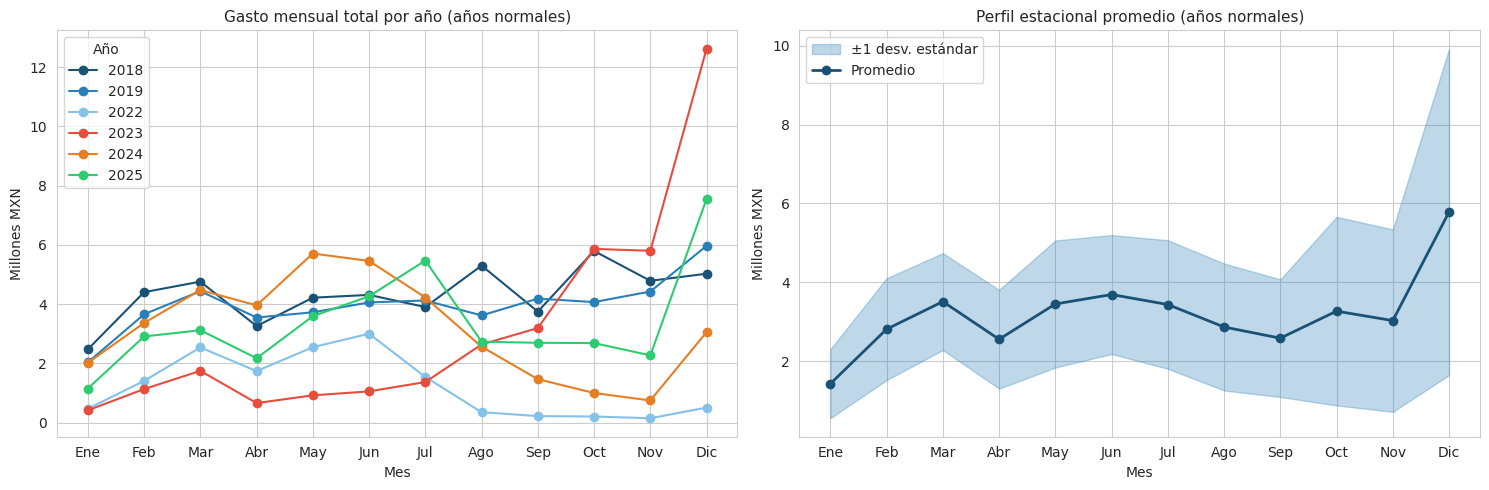


HALLAZGO – Estacionalidad:
Patrón recurrente consistente entre años:
  - Enero–Febrero: gasto moderado (inicio de ejercicio).
  - Marzo–Junio: escalada hacia el máximo de medio año.
  - Agosto: valle (vacaciones, menor actividad operativa).
  - Septiembre–Noviembre: repunte hacia el cierre del ejercicio.
  - Diciembre: caída por cierre presupuestal y fechas festivas.

→ El mes es un feature relevante y robusto para el modelo predictivo.



In [15]:
df_norm = df[df['anio'].isin([2018, 2019, 2022, 2023, 2024, 2025])]
estac = df_norm.groupby(['anio', 'mes'])['Monto Gasto'].sum().reset_index()
estac_pivot = estac.pivot(index='mes', columns='anio', values='Monto Gasto')

MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for anio in estac_pivot.columns:
    axes[0].plot(estac_pivot.index, estac_pivot[anio]/1e6, marker='o', label=str(anio), linewidth=1.5)
axes[0].set_title('Gasto mensual total por año (años normales)', fontsize=11)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Millones MXN')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MESES)
axes[0].legend(title='Año', loc='upper left')

media_mes = estac_pivot.mean(axis=1)
std_mes   = estac_pivot.std(axis=1)
axes[1].fill_between(estac_pivot.index,
                     (media_mes - std_mes)/1e6, (media_mes + std_mes)/1e6,
                     alpha=0.3, color='#2980b9', label='±1 desv. estándar')
axes[1].plot(estac_pivot.index, media_mes/1e6, color='#1a5276',
             marker='o', linewidth=2, label='Promedio')
axes[1].set_title('Perfil estacional promedio (años normales)', fontsize=11)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Millones MXN')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(MESES)
axes[1].legend()

plt.tight_layout()
plt.show()

print("""
HALLAZGO – Estacionalidad:
Patrón recurrente consistente entre años:
  - Enero–Febrero: gasto moderado (inicio de ejercicio).
  - Marzo–Junio: escalada hacia el máximo de medio año.
  - Agosto: valle (vacaciones, menor actividad operativa).
  - Septiembre–Noviembre: repunte hacia el cierre del ejercicio.
  - Diciembre: caída por cierre presupuestal y fechas festivas.

→ El mes es un feature relevante y robusto para el modelo predictivo.
""")

### 5.4 Gasto Corriente vs. Capacitación

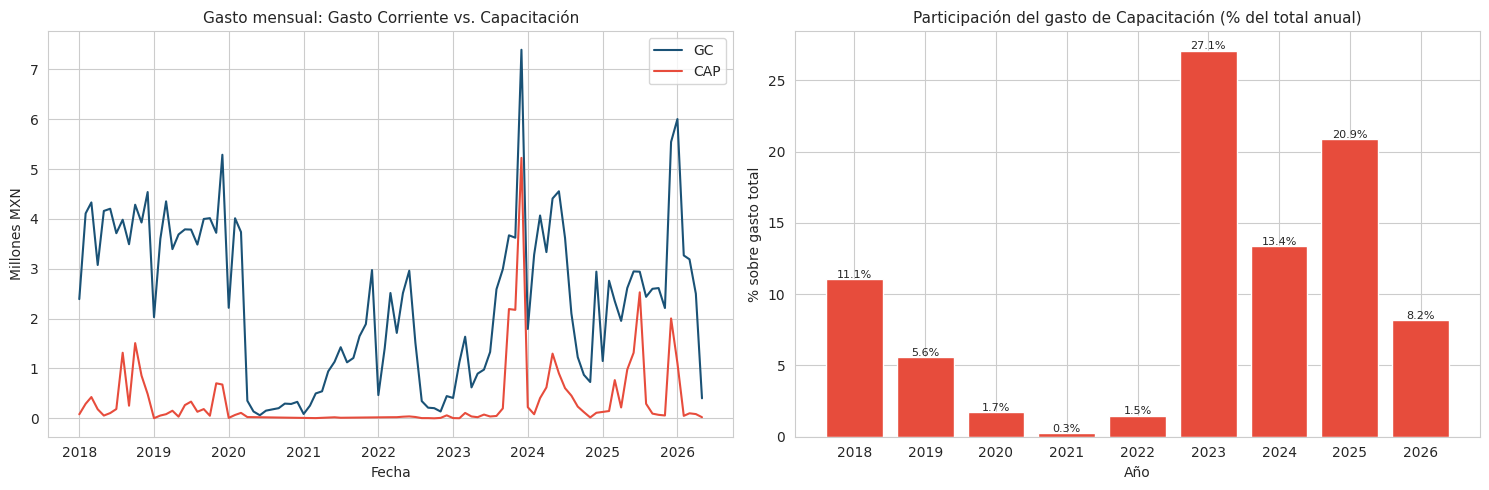


HALLAZGO – GC vs. CAP:
Los viajes de Capacitación (CAP) representan ~4–8% del gasto total pero generan
picos abruptos en periodos específicos (cursos masivos). Su comportamiento es
más difícil de predecir porque depende del calendario de eventos de FIRA.

→ Se modelarán GC y CAP por separado o se incluirá 'Grupo Tipo Viaje'
  como feature categórico con interacción con el mes y la unidad.



In [16]:
gasto_tipo = df.groupby(['anio_mes', 'Grupo Tipo Viaje'])['Monto Gasto'].sum().reset_index()
gasto_tipo['fecha'] = gasto_tipo['anio_mes'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for tipo, color in [('GC', '#1a5276'), ('CAP', '#e74c3c')]:
    data = gasto_tipo[gasto_tipo['Grupo Tipo Viaje'] == tipo]
    axes[0].plot(data['fecha'], data['Monto Gasto']/1e6, label=tipo, color=color, linewidth=1.5)
axes[0].set_title('Gasto mensual: Gasto Corriente vs. Capacitación', fontsize=11)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Millones MXN')
axes[0].legend()

part_anio = df.groupby(['anio','Grupo Tipo Viaje'])['Monto Gasto'].sum().unstack(fill_value=0)
part_anio['pct_CAP'] = part_anio.get('CAP', 0) / (part_anio.get('CAP', 0) + part_anio.get('GC', 0)) * 100
axes[1].bar(part_anio.index.astype(str), part_anio['pct_CAP'], color='#e74c3c', edgecolor='white')
axes[1].set_title('Participación del gasto de Capacitación (% del total anual)', fontsize=11)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% sobre gasto total')
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 0.1,
                 f'{p.get_height():.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("""
HALLAZGO – GC vs. CAP:
Los viajes de Capacitación (CAP) representan ~4–8% del gasto total pero generan
picos abruptos en periodos específicos (cursos masivos). Su comportamiento es
más difícil de predecir porque depende del calendario de eventos de FIRA.

→ Se modelarán GC y CAP por separado o se incluirá 'Grupo Tipo Viaje'
  como feature categórico con interacción con el mes y la unidad.
""")

### 5.5 Gasto por partida: distribución con boxplots

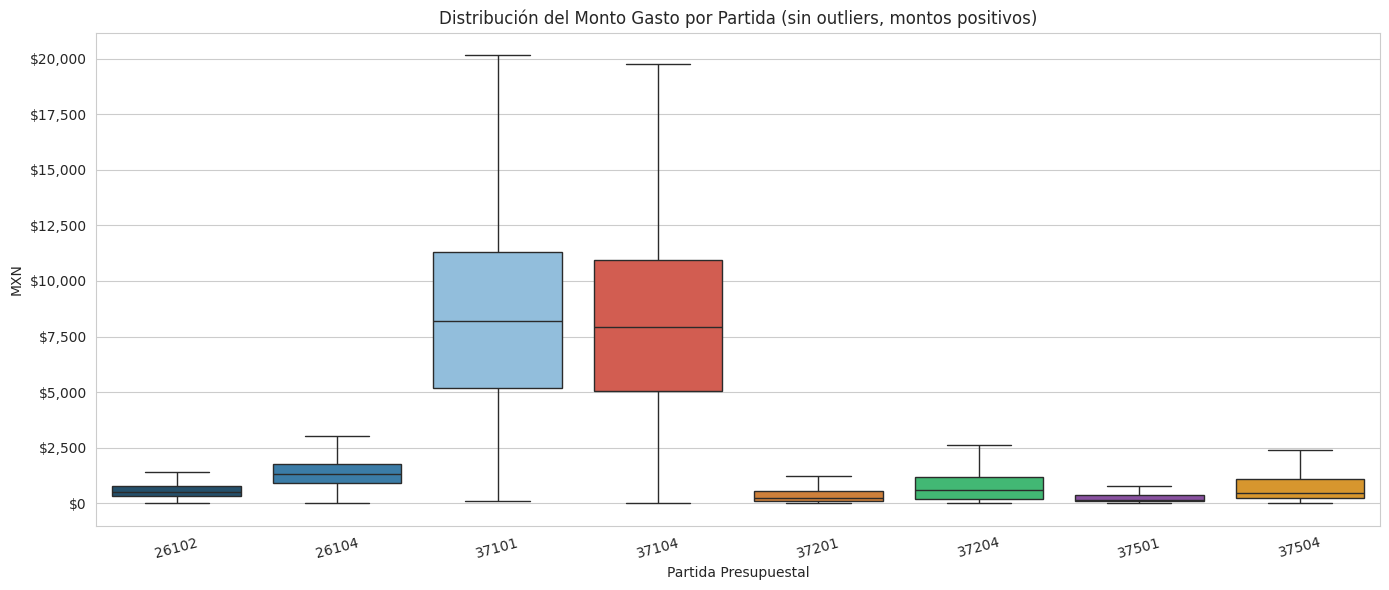

                           n    media  mediana      std       P95
Partida Presupuestal                                             
26102                 101370   649.63   500.00   500.98  1,600.11
26104                   3812 1,397.30 1,311.71   697.17  2,568.80
37101                   1953 8,509.32 8,215.47 4,340.66 16,225.80
37104                    723 8,373.31 7,923.00 4,518.19 15,483.00
37201                  53202   427.91   250.00   491.63  1,396.00
37204                   7295   715.24   600.00   557.87  1,614.99
37501                 312644   408.33   170.00   965.45  1,591.71
37504                  21550 1,104.14   460.27 1,635.53  4,755.03


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
df_pos = df[df['Monto Gasto'] > 0].copy()
df_pos['Partida'] = df_pos['Partida Presupuestal'].astype(str)

sns.boxplot(data=df_pos, x='Partida', y='Monto Gasto',
            order=[str(p) for p in PARTIDAS_MODELO],
            palette=PALETTE, showfliers=False, ax=ax)
ax.set_title('Distribución del Monto Gasto por Partida (sin outliers, montos positivos)', fontsize=12)
ax.set_xlabel('Partida Presupuestal')
ax.set_ylabel('MXN')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

stats_partida = df_pos.groupby('Partida Presupuestal')['Monto Gasto'].agg(
    ['count','mean','median','std', lambda x: x.quantile(0.95)]
).round(2)
stats_partida.columns = ['n','media','mediana','std','P95']
print(stats_partida)

### 5.6 Análisis de outliers

In [18]:
Q1 = df['Monto Gasto'].quantile(0.25)
Q3 = df['Monto Gasto'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outliers = df[df['Monto Gasto'] > upper]
print(f'Outliers por IQR (superiores): {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)')
print(f'Límite superior IQR: ${upper:,.2f}')
print('\nOutliers por partida:')
print(outliers.groupby('Partida Presupuestal').agg(
    n=('Monto Gasto','count'),
    monto_max=('Monto Gasto','max'),
    monto_mediana=('Monto Gasto','median')
))

print("""
HALLAZGO – Outliers:
Los valores extremos son plausibles dado el contexto de negocio:
  - Un funcionario con varios días de hospedaje puede llegar a $2,704/día × N días.
  - Los aviones de largo recorrido pueden superar fácilmente el límite IQR.
  - Algunos viajes tienen autorización explícita para exceder tarifas (ver sección 6).

→ No se eliminan automáticamente. En A2 se verificarán contra el tope calculado
  por viaje para etiquetar cuáles tienen excedente autorizado vs. posible error.
""")

Outliers por IQR (superiores): 49,400 (9.8%)
Límite superior IQR: $1,152.88

Outliers por partida:
                          n  monto_max  monto_mediana
Partida Presupuestal                                 
26102                 11068  12,991.78       1,548.78
26104                  2260   6,491.76       1,684.21
37101                  1928  27,729.00       8,304.17
37104                   712  37,849.80       7,998.23
37201                  5082  23,200.00       1,415.99
37204                  1956   5,875.00       1,345.01
37501                 21204  35,464.32       2,115.63
37504                  5190  30,258.80       2,802.80

HALLAZGO – Outliers:
Los valores extremos son plausibles dado el contexto de negocio:
  - Un funcionario con varios días de hospedaje puede llegar a $2,704/día × N días.
  - Los aviones de largo recorrido pueden superar fácilmente el límite IQR.
  - Algunos viajes tienen autorización explícita para exceder tarifas (ver sección 6).

→ No se eliminan automátic

### 5.7 Análisis de correlaciones

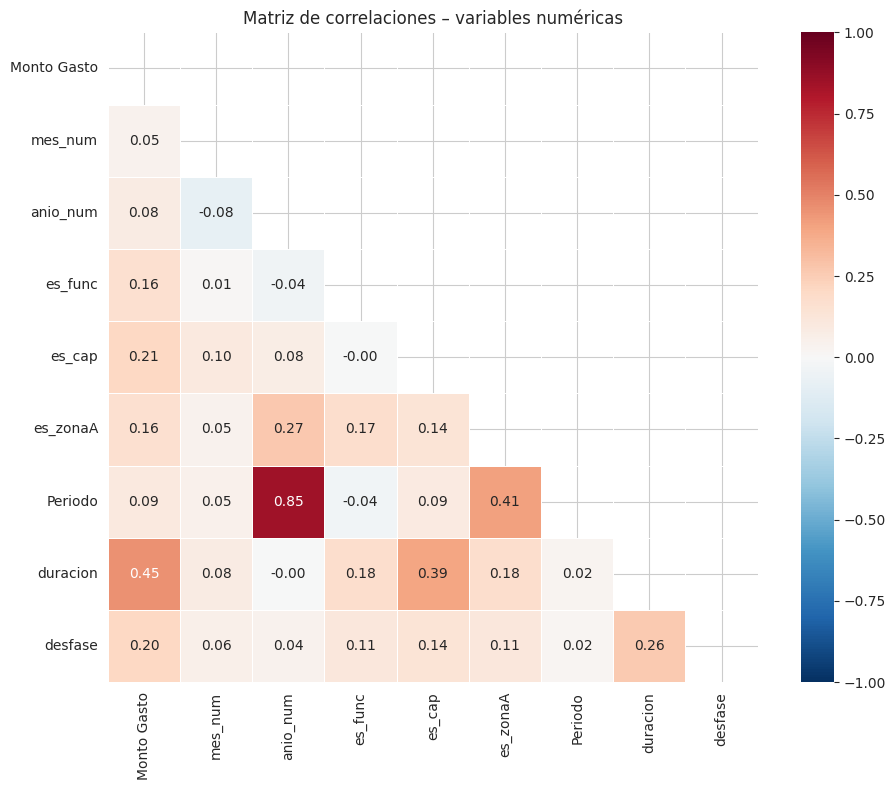

Correlaciones con Monto Gasto (ordenadas por magnitud):
duracion   0.45
es_cap     0.21
desfase    0.20
es_zonaA   0.16
es_func    0.16
Periodo    0.09
anio_num   0.08
mes_num    0.05
Name: Monto Gasto, dtype: float64

HALLAZGO – Correlaciones:
  - es_func: correlación más alta con el monto (funcionarios tienen tarifas ~65% mayores).
  - duracion: correlación positiva clara (más días → más gasto, por definición).
  - anio_num: tendencia alcista en el tiempo (inflación + crecimiento institucional).
  - Periodo: captura el cambio de tarifas a lo largo del tiempo.
  - es_zonaA: correlación positiva (Zona A tiene tarifas más altas en periodos 1 y 2).
  - mes_num: correlación baja pero no nula; captura la estacionalidad.



In [19]:
df_corr = df.copy()
df_corr['mes_num']  = df_corr['Fecha Contable'].dt.month
df_corr['anio_num'] = df_corr['Fecha Contable'].dt.year
df_corr['es_func']  = (df_corr['Funcionario o resto de personal'] == 'FUNCIONARIO').astype(int)
df_corr['es_cap']   = (df_corr['Grupo Tipo Viaje'] == 'CAP').astype(int)
df_corr['es_zonaA'] = (df_corr['Zona'] == 'Zona A').astype(int)
df_corr['duracion'] = (df_corr['Fecha Final'] - df_corr['Fecha inicio']).dt.days
df_corr['desfase']  = (df_corr['Fecha Contable'] - df_corr['Fecha inicio']).dt.days

num_cols = ['Monto Gasto','mes_num','anio_num','es_func','es_cap',
            'es_zonaA','Periodo','duracion','desfase']
corr_matrix = df_corr[num_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
ax.set_title('Matriz de correlaciones – variables numéricas', fontsize=12)
plt.tight_layout()
plt.show()

print('Correlaciones con Monto Gasto (ordenadas por magnitud):')
print(corr_matrix['Monto Gasto'].drop('Monto Gasto').sort_values(key=abs, ascending=False))

print("""
HALLAZGO – Correlaciones:
  - es_func: correlación más alta con el monto (funcionarios tienen tarifas ~65% mayores).
  - duracion: correlación positiva clara (más días → más gasto, por definición).
  - anio_num: tendencia alcista en el tiempo (inflación + crecimiento institucional).
  - Periodo: captura el cambio de tarifas a lo largo del tiempo.
  - es_zonaA: correlación positiva (Zona A tiene tarifas más altas en periodos 1 y 2).
  - mes_num: correlación baja pero no nula; captura la estacionalidad.
""")

---
## 6. Normalización de montos por cambio de tarifas

### 6.1 Marco conceptual y tabla de tarifas históricas

Las tarifas máximas de viáticos (partidas 375xx) han cambiado en tres períodos:

| Periodo | Vigencia | Cambio |
|---|---|---|
| 1 | 01/ene/2018 – 20/jul/2023 | Tarifa base con Zona A y Zona B |
| 2 | 21/jul/2023 – 29/jun/2025 | Mismas tarifas; se reclasificaron destinos (más Zona A) |
| 3 | 30/jun/2025 – presente | Tarifas únicas más altas; se elimina distinción de zonas |

El dataset ya incluye las columnas `Periodo` y `Zona` resueltas desde SAP, lo que permite aplicar la tarifa correcta a cada registro sin inferirla.

In [20]:
# =============================================================================
# TABLA DE TARIFAS HISTÓRICAS
# Clave: (periodo, zona, categoria)
# Valores: (hosp_alim, alim_sin_pernocta, cuota_dia)
# =============================================================================
TARIFAS = {
    (1, 'Zona A', 'FUNCIONARIO')       : (2290, 647, 230),
    (1, 'Zona B', 'FUNCIONARIO')       : (1810, 600, 230),
    (1, 'Zona A', 'RESTO DE PERSONAL') : (1510, 600, 170),
    (1, 'Zona B', 'RESTO DE PERSONAL') : (1290, 600, 170),
    # Periodo 2: mismas tarifas, diferente clasificación de destinos
    (2, 'Zona A', 'FUNCIONARIO')       : (2290, 647, 230),
    (2, 'Zona B', 'FUNCIONARIO')       : (1810, 600, 230),
    (2, 'Zona A', 'RESTO DE PERSONAL') : (1510, 600, 170),
    (2, 'Zona B', 'RESTO DE PERSONAL') : (1290, 600, 170),
    # Periodo 3: tarifa única, todos registrados como Zona A
    (3, 'Zona A', 'FUNCIONARIO')       : (2704, 647, 260),
    (3, 'Zona A', 'RESTO DE PERSONAL') : (1635, 620, 230),
}

# Mostrar la tabla de forma legible
rows = []
for (periodo, zona, cat), (hosp_alim, alim_sp, cuota) in TARIFAS.items():
    rows.append({'Periodo': periodo, 'Zona': zona, 'Categoría': cat,
                 'Hosp+Alim': hosp_alim, 'Alim sin pernocta': alim_sp, 'Cuota/día': cuota})
pd.DataFrame(rows).sort_values(['Periodo','Zona','Categoría'])

,Periodo,Zona,Categoría,Hosp+Alim,Alim sin pernocta,Cuota/día
0,1,Zona A,FUNCIONARIO,2290,647,230
2,1,Zona A,RESTO DE PERSONAL,1510,600,170
1,1,Zona B,FUNCIONARIO,1810,600,230
3,1,Zona B,RESTO DE PERSONAL,1290,600,170
4,2,Zona A,FUNCIONARIO,2290,647,230
6,2,Zona A,RESTO DE PERSONAL,1510,600,170
5,2,Zona B,FUNCIONARIO,1810,600,230
7,2,Zona B,RESTO DE PERSONAL,1290,600,170
8,3,Zona A,FUNCIONARIO,2704,647,260
9,3,Zona A,RESTO DE PERSONAL,1635,620,230


### 6.2 Lógica del tope por viaje (empleado–viaje)

El tope máximo de viáticos se calcula a nivel **empleado–viaje**, no por concepto individual.  
Un empleado puede hacer varias comprobaciones para el mismo viaje (inicial + complementarias).

**Regla de cálculo:**
- Si el viaje dura **1 día**: tope_alim = `alim_sin_pernocta`
- Si el viaje dura **N días (N > 1)**: tope_alim = `(N−1) × hosp_alim + 1 × alim_sin_pernocta`
- Cuota sin comprobar (independiente): tope_cuota = `N × cuota_dia`

In [21]:
def calcular_tope_viaje(dias, periodo, zona, categoria):
    """
    Calcula el tope máximo de viáticos (alimentos y cuota) para un viaje.
    Retorna (tope_alim, tope_cuota, tope_total) o (None, None, None) si
    la clave no existe en la tabla de tarifas.
    """
    key = (int(periodo), zona, categoria)
    if key not in TARIFAS:
        return (None, None, None)
    hosp_alim, alim_sin_pernocta, cuota = TARIFAS[key]
    if dias == 1:
        tope_alim = alim_sin_pernocta
    else:
        tope_alim = (dias - 1) * hosp_alim + alim_sin_pernocta
    tope_cuota = dias * cuota
    return (tope_alim, tope_cuota, tope_alim + tope_cuota)


# Verificación con los ejemplos del enunciado
print('Ejemplo 1 – Funcionario, Zona A, 1 día (periodo 1):')
print('  Resultado:', calcular_tope_viaje(1, 1, 'Zona A', 'FUNCIONARIO'))
print('  Esperado:  alim_sin_pernocta = 647, cuota = 230, total = 877')

print('\nEjemplo 2 – Resto personal, Zona B, 3 días (periodo 1):')
print('  Resultado:', calcular_tope_viaje(3, 1, 'Zona B', 'RESTO DE PERSONAL'))
print('  Esperado:  2×1290 + 600 = 3180 alim, 3×170 = 510 cuota, total = 3690')

Ejemplo 1 – Funcionario, Zona A, 1 día (periodo 1):
  Resultado: (647, 230, 877)
  Esperado:  alim_sin_pernocta = 647, cuota = 230, total = 877

Ejemplo 2 – Resto personal, Zona B, 3 días (periodo 1):
  Resultado: (3180, 510, 3690)
  Esperado:  2×1290 + 600 = 3180 alim, 3×170 = 510 cuota, total = 3690


### 6.3 Cálculo de topes y fracción ejercida por empleado–viaje

In [22]:
CONCEPTOS_ALIM  = ['Alimentación-Hospedaje', 'Alimentación sin Pernocta']
CONCEPTOS_CUOTA = ['Cuota sin comprobar']
CONCEPTOS_TOPE  = CONCEPTOS_ALIM + CONCEPTOS_CUOTA

# Dataset de viáticos con tope definido
df_viat = df[
    df['Partida Presupuestal'].isin([37501, 37504]) &
    df['Concepto'].isin(CONCEPTOS_TOPE) &
    df['Fecha inicio'].notna() &
    df['Clave Empleado'].notna()
].copy()

df_viat['dias_viaje'] = (df_viat['Fecha Final'] - df_viat['Fecha inicio']).dt.days + 1

# Agregar gasto por empleado-viaje separando alimentos y cuota
ID_VIAJE = ['Clave Empleado', 'Viaje']

gasto_alim = (df_viat[df_viat['Concepto'].isin(CONCEPTOS_ALIM)]
              .groupby(ID_VIAJE)['Monto Gasto'].sum().rename('gasto_alim'))

gasto_cuota = (df_viat[df_viat['Concepto'].isin(CONCEPTOS_CUOTA)]
               .groupby(ID_VIAJE)['Monto Gasto'].sum().rename('gasto_cuota'))

# Atributos del viaje (constantes dentro del mismo empleado-viaje)
atribs = (df_viat.groupby(ID_VIAJE)
          .agg(
              categoria = ('Funcionario o resto de personal', 'first'),
              zona      = ('Zona', 'first'),
              periodo   = ('Periodo', 'first'),
              dias      = ('dias_viaje', 'first'),
          ).reset_index())

viajes = (atribs
          .join(gasto_alim,  on=ID_VIAJE)
          .join(gasto_cuota, on=ID_VIAJE))
viajes['gasto_alim']  = viajes['gasto_alim'].fillna(0)
viajes['gasto_cuota'] = viajes['gasto_cuota'].fillna(0)

# Calcular topes
topes = viajes.apply(
    lambda r: calcular_tope_viaje(int(r['dias']), int(r['periodo']), r['zona'], r['categoria']),
    axis=1
)
viajes[['tope_alim', 'tope_cuota', 'tope_total']] = pd.DataFrame(topes.tolist(), index=viajes.index)

# Fracciones ejercidas
viajes['fraccion_alim']  = viajes['gasto_alim']  / viajes['tope_alim'].replace(0, np.nan)
viajes['fraccion_cuota'] = viajes['gasto_cuota'] / viajes['tope_cuota'].replace(0, np.nan)
viajes['fraccion_total'] = (viajes['gasto_alim'] + viajes['gasto_cuota']) / viajes['tope_total'].replace(0, np.nan)

print(f'Viajes únicos (empleado–viaje) con tope calculado: {viajes["tope_alim"].notna().sum():,}')
print(f'\nFracción alimentos ejercida:')
print(viajes['fraccion_alim'].describe().to_frame().T.round(3))
print(f'\nFracción cuota ejercida:')
print(viajes['fraccion_cuota'].describe().to_frame().T.round(3))
print(f'\nFracción total ejercida:')
print(viajes['fraccion_total'].describe().to_frame().T.round(3))

Viajes únicos (empleado–viaje) con tope calculado: 146,567

Fracción alimentos ejercida:
                   count  mean  std  min  25%  50%  75%  max
fraccion_alim 146,567.00  0.42 0.37 0.00 0.00 0.46 0.70 3.47

Fracción cuota ejercida:
                    count  mean  std  min  25%  50%  75%  max
fraccion_cuota 146,567.00  0.75 0.19 0.00 0.62 0.62 1.00 9.13

Fracción total ejercida:
                    count  mean  std  min  25%  50%  75%  max
fraccion_total 146,567.00  0.49 0.30 0.02 0.17 0.51 0.72 3.12


### 6.4 Distribución de fracciones y viajes que exceden el tope

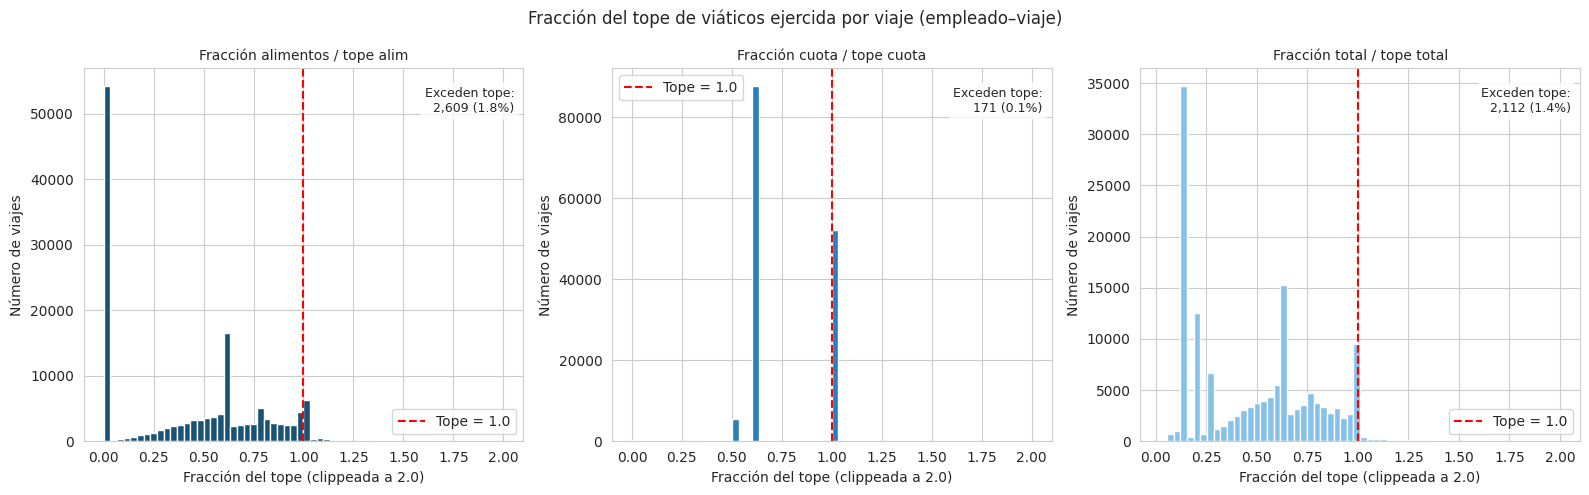

Viajes que exceden el tope total: 2,112

Por categoría:
categoria
RESTO DE PERSONAL    2011
FUNCIONARIO           101
Name: count, dtype: int64

Por periodo:
periodo
1    915
2    814
3    383
Name: count, dtype: int64

Fracción mediana de los excedentes: 1.13
Fracción máxima de los excedentes: 3.123

HALLAZGO – Excedentes de tarifa:
Un subconjunto de viajes supera el tope máximo de viáticos. Conforme a las reglas
de negocio de FIRA, esto es válido para viajes con autorización explícita.
No se tratan como errores.

→ En A2 se creará una variable binaria 'excede_tope' que el modelo podrá usar
  para capturar este patrón sin eliminarlo.



In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fracs = [
    ('fraccion_alim',  'Fracción alimentos / tope alim', '#1a5276'),
    ('fraccion_cuota', 'Fracción cuota / tope cuota',    '#2980b9'),
    ('fraccion_total', 'Fracción total / tope total',    '#85c1e9'),
]

for i, (col, titulo, color) in enumerate(fracs):
    data = viajes[col].dropna()
    data_clip = data.clip(0, 2)
    axes[i].hist(data_clip, bins=60, color=color, edgecolor='white')
    axes[i].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Tope = 1.0')
    axes[i].set_title(titulo, fontsize=10)
    axes[i].set_xlabel('Fracción del tope (clippeada a 2.0)')
    axes[i].set_ylabel('Número de viajes')
    n_excede = (data > 1.0).sum()
    pct_excede = n_excede / len(data) * 100
    axes[i].legend()
    axes[i].text(0.98, 0.95, f'Exceden tope:\n{n_excede:,} ({pct_excede:.1f}%)',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Fracción del tope de viáticos ejercida por viaje (empleado–viaje)', fontsize=12)
plt.tight_layout()
plt.show()

# Desglose de excedentes por categoria y periodo
excedentes = viajes[viajes['fraccion_total'] > 1.0]
print(f'Viajes que exceden el tope total: {len(excedentes):,}')
print('\nPor categoría:')
print(excedentes['categoria'].value_counts())
print('\nPor periodo:')
print(excedentes['periodo'].value_counts().sort_index())
print('\nFracción mediana de los excedentes:', excedentes['fraccion_total'].median().round(3))
print('Fracción máxima de los excedentes:',  excedentes['fraccion_total'].max().round(3))

print("""
HALLAZGO – Excedentes de tarifa:
Un subconjunto de viajes supera el tope máximo de viáticos. Conforme a las reglas
de negocio de FIRA, esto es válido para viajes con autorización explícita.
No se tratan como errores.

→ En A2 se creará una variable binaria 'excede_tope' que el modelo podrá usar
  para capturar este patrón sin eliminarlo.
""")

### 6.5 Tendencia de la fracción ejercida en el tiempo

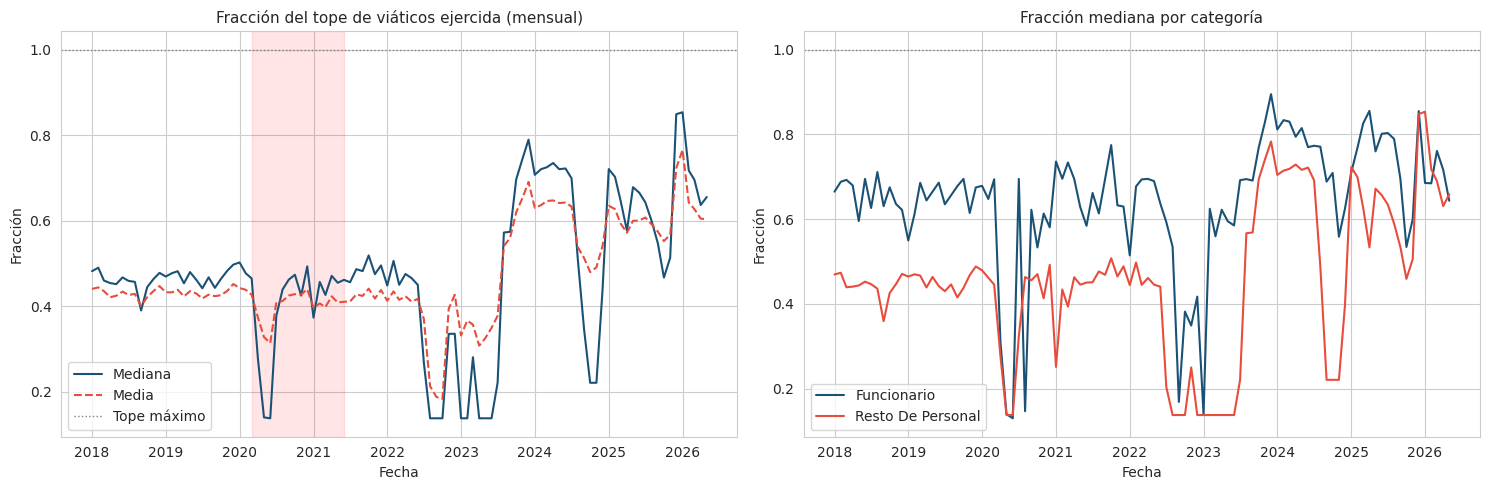


HALLAZGO – Tendencia de la fracción ejercida:
La fracción mediana es estable en el tiempo (~0.5), lo que confirma que los empleados
no agotan sistemáticamente su tope. Los funcionarios muestran fracciones ligeramente
más altas que el resto de personal.

La estabilidad de la fracción a través de los cambios de tarifa (periodos 1→2→3)
valida la estrategia de normalización: los empleados ajustan su comportamiento
de gasto proporcionalmente al tope disponible.

→ La variable 'fraccion_total' es un feature robusto para el modelo porque
  es comparable entre períodos con distintas tarifas.



In [24]:
# Unir fraccion_total al dataset de viáticos para análisis temporal
df_frac = (df_viat[ID_VIAJE + ['Fecha Contable']]
           .drop_duplicates(subset=ID_VIAJE)
           .merge(viajes[ID_VIAJE + ['fraccion_total', 'fraccion_alim', 'fraccion_cuota',
                                      'categoria', 'periodo']],
                  on=ID_VIAJE, how='left'))
df_frac['anio_mes'] = df_frac['Fecha Contable'].dt.to_period('M')

frac_mes = df_frac.groupby('anio_mes')['fraccion_total'].agg(['mean','median']).reset_index()
frac_mes['fecha'] = frac_mes['anio_mes'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Serie temporal de fracción
axes[0].plot(frac_mes['fecha'], frac_mes['median'], color='#1a5276',
             label='Mediana', linewidth=1.5)
axes[0].plot(frac_mes['fecha'], frac_mes['mean'], color='#e74c3c',
             label='Media', linewidth=1.5, linestyle='--')
axes[0].axhline(1.0, color='gray', linestyle=':', linewidth=1, label='Tope máximo')
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
                alpha=0.1, color='red')
axes[0].set_title('Fracción del tope de viáticos ejercida (mensual)', fontsize=11)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Fracción')
axes[0].legend()

# Por categoría
for cat, color in [('FUNCIONARIO', '#1a5276'), ('RESTO DE PERSONAL', '#e74c3c')]:
    data = (df_frac[df_frac['categoria'] == cat]
            .groupby('anio_mes')['fraccion_total'].median().reset_index())
    data['fecha'] = data['anio_mes'].dt.to_timestamp()
    axes[1].plot(data['fecha'], data['fraccion_total'], color=color,
                 label=cat.title(), linewidth=1.5)
axes[1].axhline(1.0, color='gray', linestyle=':', linewidth=1)
axes[1].set_title('Fracción mediana por categoría', fontsize=11)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Fracción')
axes[1].legend()

plt.tight_layout()
plt.show()

print("""
HALLAZGO – Tendencia de la fracción ejercida:
La fracción mediana es estable en el tiempo (~0.5), lo que confirma que los empleados
no agotan sistemáticamente su tope. Los funcionarios muestran fracciones ligeramente
más altas que el resto de personal.

La estabilidad de la fracción a través de los cambios de tarifa (periodos 1→2→3)
valida la estrategia de normalización: los empleados ajustan su comportamiento
de gasto proporcionalmente al tope disponible.

→ La variable 'fraccion_total' es un feature robusto para el modelo porque
  es comparable entre períodos con distintas tarifas.
""")

### 6.6 Normalización para partidas sin tope tarifario (261xx, 372xx, 371xx)

Las partidas de gasolina, transporte terrestre y aviones **no tienen tope tarifario diario** → no aplica la fracción de tarifa.  
Para estas partidas se usará deflactación por **INPC** (Índice Nacional de Precios al Consumidor, base dic-2024):

$$\text{monto\_real} = \text{monto\_nominal} \times \frac{\text{INPC}_{\text{base}}}{\text{INPC}_{\text{mes}}}$$

El INPC mensual histórico se integrará como fuente externa en **A2** (disponible en BANXICO).

**Nota especial – Partidas 371xx (aviones):**  
Solo disponibles a partir de septiembre 2020 (inicio del proceso con agencia externa). El modelo predictivo para estas partidas usará únicamente el histórico sep-2020 en adelante.

---
## 7. Vista anticipada: distribución del gasto por centro de costo

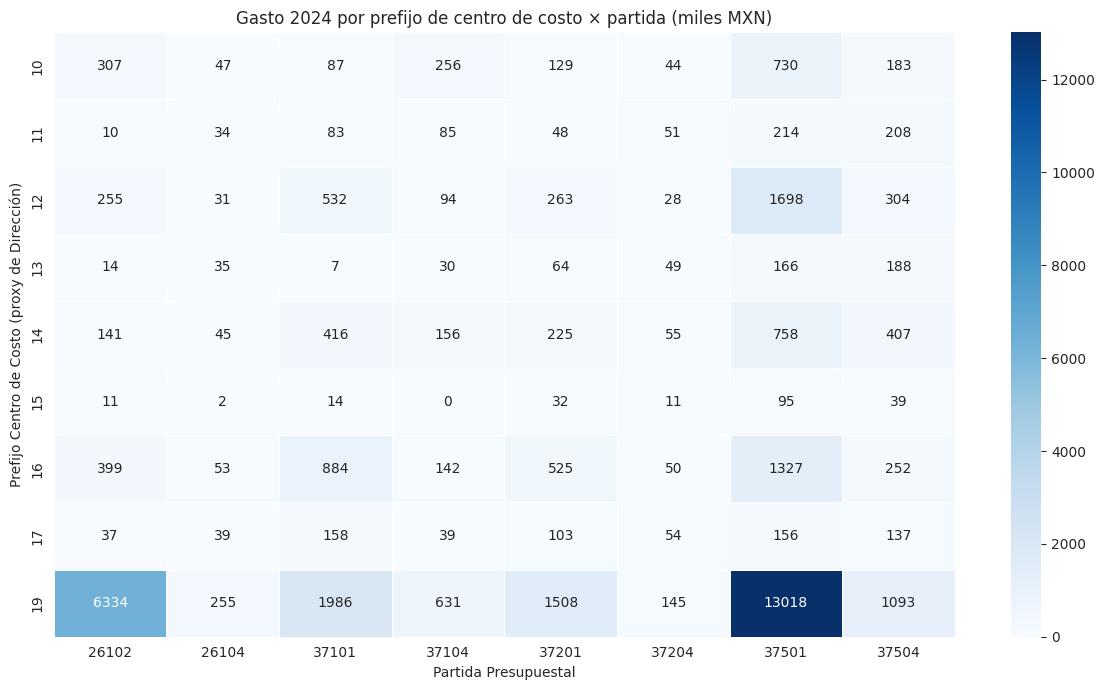


HALLAZGO – Distribución por unidad y partida:
El heatmap muestra heterogeneidad importante entre unidades:
  - Algunas unidades concentran la mayor parte del gasto en viáticos (375xx).
  - La gasolina (261xx) está más distribuida entre unidades.
  - Aviones (371xx) tienen alta concentración en pocas unidades.

→ Este patrón respalda la necesidad de modelos diferenciados por unidad × partida.
  El clustering (A4) ayudará a identificar unidades con comportamiento similar.
→ Pendiente A2: integrar tabla de mapeo CC → Centro Gestor → Unidad de primer nivel.



In [25]:
# Proxy de agrupación usando prefijo del centro de costo
# En A2 se usará la tabla de mapeo completa: CC → Centro Gestor → Unidad de primer nivel
df['prefijo_cc'] = (df['Clave Centro Costo'] // 1000000).astype(str).str.zfill(2)

pivot_2024 = (df[df['anio'] == 2024]
              .groupby(['prefijo_cc', 'Partida Presupuestal'])['Monto Gasto']
              .sum()
              .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot_2024/1e3, annot=True, fmt='.0f', cmap='Blues',
            ax=ax, linewidths=0.5)
ax.set_title('Gasto 2024 por prefijo de centro de costo × partida (miles MXN)', fontsize=12)
ax.set_xlabel('Partida Presupuestal')
ax.set_ylabel('Prefijo Centro de Costo (proxy de Dirección)')
plt.tight_layout()
plt.show()

print("""
HALLAZGO – Distribución por unidad y partida:
El heatmap muestra heterogeneidad importante entre unidades:
  - Algunas unidades concentran la mayor parte del gasto en viáticos (375xx).
  - La gasolina (261xx) está más distribuida entre unidades.
  - Aviones (371xx) tienen alta concentración en pocas unidades.

→ Este patrón respalda la necesidad de modelos diferenciados por unidad × partida.
  El clustering (A4) ayudará a identificar unidades con comportamiento similar.
→ Pendiente A2: integrar tabla de mapeo CC → Centro Gestor → Unidad de primer nivel.
""")

---
## 8. Conclusiones del EDA

In [26]:
print("""
=============================================================================
CONCLUSIONES DEL EDA – Avance 1
=============================================================================

1. CALIDAD DE DATOS
   - Dataset de alta calidad: <0.02% de nulos, todos en partidas de avión
     con causa de negocio identificada (vuelos no realizados / sin trazabilidad).
   - 94 montos negativos (ajustes válidos): se conservan en el gasto neto.
   - Partida 32502 (110 registros, Renta de Vehículo): excluida del modelo.

2. DESFASE CONTABLE
   - Mediana de ~7–14 días entre fecha de viaje y fecha contable.
   - Se usará FECHA CONTABLE como referencia presupuestal.

3. DISTRIBUCIÓN
   - Fuertemente asimétrica (skew > 8). La transformación log(1+x) la normaliza.
   - Las dos jorobas en escala log reflejan funcionarios vs. resto de personal.
   - Baseline lineal (A3) requerirá transformación; XGBoost/RF son robustos sin ella.

4. ESTACIONALIDAD Y TENDENCIAS
   - Patrón estacional consistente entre años: valle en agosto, pico en nov.
   - COVID 2020–2021: período atípico que se tratará de forma diferenciada.
   - Tendencia alcista a largo plazo (inflación + crecimiento institucional).

5. TIPO DE VIAJE (GC vs. CAP)
   - CAP representa ~4–8% del gasto pero genera picos concentrados.
   - Se modelará como feature categórico con interacción con mes y unidad.

6. NORMALIZACIÓN POR TARIFAS (partidas 375xx)
   - Se calculó el tope máximo por viaje (empleado–viaje) usando:
       · Categoría del empleado (funcionario / resto)
       · Zona del destino (A / B, según periodo)
       · Duración del viaje (días)
       · Período tarifario (1, 2 o 3, ya resuelto en el dataset)
   - La fracción ejercida (gasto / tope) es estable a través del tiempo,
     validando su uso como variable normalizada comparable entre períodos.
   - Los viajes que exceden el tope (~2,600) son autorizaciones válidas,
     no errores; se etiquetarán con 'excede_tope' en A2.
   - Para partidas 261xx, 372xx, 371xx: deflactación por INPC (A2).
   - Partidas 371xx: histórico disponible solo desde sep-2020.

7. HETEROGENEIDAD POR UNIDAD
   - El gasto por unidad y partida es muy heterogéneo: justifica modelos
     diferenciados y clustering de unidades similares (A4).

8. CORRELACIONES
   - Factores más relevantes: categoría empleado, duración del viaje,
     año (tendencia), zona y periodo (tarifas).

PENDIENTES PARA A2 (Feature Engineering)
   □ Tabla de mapeo: CC → Centro Gestor → Unidad de primer nivel (13 unidades)
   □ INPC mensual histórico (BanxICo) para deflactación de 261xx / 372xx / 371xx
   □ Variable 'excede_tope' (binaria) por viaje
   □ Plantilla de empleados histórica por unidad × mes × categoría
   □ Topes presupuestales anuales por partida (fuente SHCP / sponsor)
=============================================================================
""")


CONCLUSIONES DEL EDA – Avance 1

1. CALIDAD DE DATOS
   - Dataset de alta calidad: <0.02% de nulos, todos en partidas de avión
     con causa de negocio identificada (vuelos no realizados / sin trazabilidad).
   - 94 montos negativos (ajustes válidos): se conservan en el gasto neto.
   - Partida 32502 (110 registros, Renta de Vehículo): excluida del modelo.

2. DESFASE CONTABLE
   - Mediana de ~7–14 días entre fecha de viaje y fecha contable.
   - Se usará FECHA CONTABLE como referencia presupuestal.

3. DISTRIBUCIÓN
   - Fuertemente asimétrica (skew > 8). La transformación log(1+x) la normaliza.
   - Las dos jorobas en escala log reflejan funcionarios vs. resto de personal.
   - Baseline lineal (A3) requerirá transformación; XGBoost/RF son robustos sin ella.

4. ESTACIONALIDAD Y TENDENCIAS
   - Patrón estacional consistente entre años: valle en agosto, pico en nov.
   - COVID 2020–2021: período atípico que se tratará de forma diferenciada.
   - Tendencia alcista a largo plazo (inflac

---
## Referencias
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly Media. Caps. 2, 3.
- Visengeriyeva et al. (2023). *CRISP-ML(Q) – The ML Lifecycle Process*. MLOps/INNOQ. https://ml-ops.org/content/crisp-ml
- Avance 0 – Propuesta de Proyecto. TC5035 Equipo 35. Mayo 2026.